In [9]:
def read_csv(path):
    xs = []
    ys = []
    f = open(path, "r")
    for line in f:
        line = line.strip()
        if line == "":
            continue
        parts = line.split(",")
        x = float(parts[0])
        y = float(parts[1])
        xs.append(x)
        ys.append(y)
    f.close()
    return xs, ys

xs, ys = read_csv("../Dataset/lr.csv")
N = len(xs)

print("Loaded", N, "points")
for i in range(N):
    print("  x =", xs[i], ", y =", ys[i])


Loaded 5 points
  x = 10.0 , y = 55.0
  x = 20.0 , y = 80.0
  x = 40.0 , y = 100.0
  x = 60.0 , y = 120.0
  x = 80.0 , y = 150.0


In [10]:
def predict(x, w0, w1):
    return w1 * x + w0

def loss(w0, w1):
    s = 0.0
    for i in range(N):
        e = predict(xs[i], w0, w1) - ys[i]
        s = s + e * e
    return 0.5 * s / N

In [11]:
def train(w0, w1, r, iters):
    for it in range(iters):
        for i in range(N):
            e = w1 * xs[i] + w0 - ys[i]
            w0 = w0 - r * e
            w1 = w1 - r * xs[i] * e
        print(f"Iteration {it+1}: w0 = {w0:.6f}, w1 = {w1:.6f}, J = {loss(w0, w1):.6f}")
    return w0, w1

w0, w1 = train(0.0, 1.0, 0.0001, 100)
print(f"\nFinal model: y = {w1:.6f} * x + {w0:.6f}")
print(f"w1 = {w1:.6f}")
print(f"w0 = {w0:.6f}")

Iteration 1: w0 = 0.021680, w1 = 1.776280, J = 443.945005
Iteration 2: w0 = 0.031198, w1 = 1.918899, J = 358.475652
Iteration 3: w0 = 0.038480, w1 = 1.945037, J = 348.054622
Iteration 4: w0 = 0.045349, w1 = 1.949763, J = 346.242800
Iteration 5: w0 = 0.052142, w1 = 1.950552, J = 345.838155
Iteration 6: w0 = 0.058920, w1 = 1.950619, J = 345.686248
Iteration 7: w0 = 0.065695, w1 = 1.950552, J = 345.580615
Iteration 8: w0 = 0.072468, w1 = 1.950461, J = 345.483502
Iteration 9: w0 = 0.079240, w1 = 1.950365, J = 345.387977
Iteration 10: w0 = 0.086011, w1 = 1.950268, J = 345.292766
Iteration 11: w0 = 0.092781, w1 = 1.950172, J = 345.197634
Iteration 12: w0 = 0.099550, w1 = 1.950075, J = 345.102540
Iteration 13: w0 = 0.106319, w1 = 1.949978, J = 345.007474
Iteration 14: w0 = 0.113086, w1 = 1.949882, J = 344.912435
Iteration 15: w0 = 0.119852, w1 = 1.949785, J = 344.817424
Iteration 16: w0 = 0.126617, w1 = 1.949688, J = 344.722439
Iteration 17: w0 = 0.133382, w1 = 1.949592, J = 344.627482
Iterat

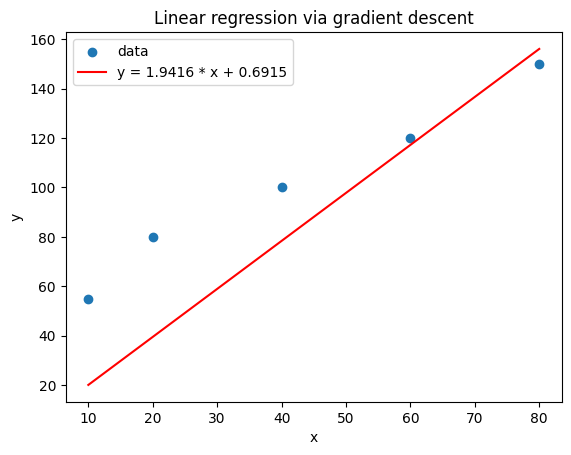

In [12]:
import matplotlib.pyplot as plt

x_line = [min(xs), max(xs)]
y_line = [w1 * x + w0 for x in x_line]

plt.scatter(xs, ys, label="data")
plt.plot(x_line, y_line, color="red", label=f"y = {w1:.4f} * x + {w0:.4f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression via gradient descent")
plt.legend()
plt.show()